# Análisis Predictivo de Engagement

In [45]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


Realizamos los import y establecemos la semilla para reproducibilidad

In [46]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from pathlib import Path
RANDOM_SEED = 26
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Librerías importadas y semilla fijada.")

Librerías importadas y semilla fijada.


Cargamos el dataframe y lo visualizamos

In [47]:
ruta_csv = "../data/poi_dataset.csv"
df = pd.read_csv(ruta_csv)

print("Forma del dataset:", df.shape)
display(df.head())
print("\nInformación de las columnas y nulos:")
print(df.info())
display(df.describe())

Forma del dataset: (1569, 14)


,id,name,shortDescription,categories,tier,locationLon,locationLat,tags,xps,Visits,Likes,Dislikes,Bookmarks,main_image_path
0,4b36a3ed-3b28-4bc7-b975-1d48b586db03,Galería Fran Reus,La Galería Fran Reus es un espacio dedicado a ...,"['Escultura', 'Pintura']",1,2.642262,39.572694,[],500,10009,422,3582,78,data_main/4b36a3ed-3b28-4bc7-b975-1d48b586db03...
1,e32b3603-a94f-49df-8b31-92445a86377c,Convento de San Plácido,"El Convento de San Plácido en Madrid, fundado ...","['Patrimonio', 'Historia']",1,-3.704467,40.423037,[],500,10010,7743,96,2786,data_main/e32b3603-a94f-49df-8b31-92445a86377c...
2,0123a69b-13ac-4b65-a5d5-71a95560cff5,Instituto Geológico y Minero de España,"El Instituto Geológico y Minero de España, sit...","['Ciencia', 'Patrimonio']",2,-3.699694,40.442045,[],250,10015,3154,874,595,data_main/0123a69b-13ac-4b65-a5d5-71a95560cff5...
3,390d7d9e-e972-451c-b5e4-f494af15e788,Margarita Gil Roësset,"Margarita Gil Roësset, escultora y poetisa esp...",['Cultura'],1,-3.691228,40.427256,[],500,10011,8559,79,2358,data_main/390d7d9e-e972-451c-b5e4-f494af15e788...
4,023fc1bf-a1cd-4b9f-af78-48792ab1a294,Museo del Traje. Centro de Investigación del P...,"El Museo del Traje de Madrid, fundado en 2004,...","['Patrimonio', 'Cultura']",1,-3.727822,40.439665,[],500,10020,915,2896,143,data_main/023fc1bf-a1cd-4b9f-af78-48792ab1a294...



Información de las columnas y nulos:
<class 'pandas.DataFrame'>
RangeIndex: 1569 entries, 0 to 1568
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                1569 non-null   str    
 1   name              1569 non-null   str    
 2   shortDescription  1569 non-null   str    
 3   categories        1569 non-null   str    
 4   tier              1569 non-null   int64  
 5   locationLon       1569 non-null   float64
 6   locationLat       1569 non-null   float64
 7   tags              1569 non-null   str    
 8   xps               1569 non-null   int64  
 9   Visits            1569 non-null   int64  
 10  Likes             1569 non-null   int64  
 11  Dislikes          1569 non-null   int64  
 12  Bookmarks         1569 non-null   int64  
 13  main_image_path   1569 non-null   str    
dtypes: float64(2), int64(6), str(6)
memory usage: 171.7 KB
None


,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks
count,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000
mean,1.541109,-1.132337,39.900141,750.382409,10011.943276,3623.908222,2526.305927,973.261950
std,0.637677,22.733401,9.662134,228.319854,5.456808,4817.879374,2225.543360,1453.333948
min,1.000000,-121.951049,-62.940930,0.000000,10001.000000,100.000000,52.000000,50.000000
25%,1.000000,-3.725292,40.411754,600.000000,10008.000000,464.000000,937.000000,116.000000
50%,1.000000,-3.699140,40.421738,700.000000,10011.000000,1434.000000,2718.000000,306.000000
75%,2.000000,-3.673348,40.472458,1000.000000,10015.000000,6840.000000,3399.000000,1309.000000
max,4.000000,158.333118,65.706572,1000.000000,10038.000000,26425.000000,10999.000000,8157.000000


Cambiamos la ruta del df para poder usar las imagenes correctamente

In [48]:
df['main_image_path'] = df['main_image_path'].apply(
    lambda x: str(Path("../data") / x)
)

Creo la variable target para calcular el engagement y luego poder predecir sobre esta mediante una formula que es like-dislikes + 2*Bookmarks nos deshacemos del valor de visitas ya que parece estar truncado a 10000 ya que no tiene std practicamente y le damos mas valor a los bookmarks ya que consideramos que tiene mas relevancia, además fijamos un buen engagement en por encima de la mediana

In [49]:
df['engagement_score'] = (df['Likes'] - df['Dislikes']) + (2 * df['Bookmarks'])

mediana_engagement = df['engagement_score'].median()
df['target_engagement'] = (df['engagement_score'] >= mediana_engagement).astype(int)

print(f"Mediana de engagement calculada: {mediana_engagement}")
print("Distribución de la variable objetivo (0 = Bajo, 1 = Alto):")
print(df['target_engagement'].value_counts())

Mediana de engagement calculada: -1609.0
Distribución de la variable objetivo (0 = Bajo, 1 = Alto):
target_engagement
1    785
0    784
Name: count, dtype: int64


Dividimos el dataframe en train test validacion estratificando

In [50]:
from sklearn.model_selection import train_test_split

print(f"Total de datos antes de dividir: {len(df)}")

df_train, df_temp = train_test_split(
    df, 
    test_size=0.30, 
    random_state=RANDOM_SEED, 
    stratify=df['target_engagement']
)

df_val, df_test = train_test_split(
    df_temp, 
    test_size=0.50, 
    random_state=RANDOM_SEED, 
    stratify=df_temp['target_engagement']
)

print(f"Tamaño de Train: {len(df_train)} ({(len(df_train)/len(df))*100:.1f}%)")
print(f"Tamaño de Validation: {len(df_val)} ({(len(df_val)/len(df))*100:.1f}%)")
print(f"Tamaño de Test: {len(df_test)} ({(len(df_test)/len(df))*100:.1f}%)")

print("\nProporción de clases en Train:")
print(df_train['target_engagement'].value_counts(normalize=True))
print("\nProporción de clases en Validation:")
print(df_val['target_engagement'].value_counts(normalize=True))

Total de datos antes de dividir: 1569
Tamaño de Train: 1098 (70.0%)
Tamaño de Validation: 235 (15.0%)
Tamaño de Test: 236 (15.0%)

Proporción de clases en Train:
target_engagement
1    0.5
0    0.5
Name: proportion, dtype: float64

Proporción de clases en Validation:
target_engagement
1    0.502128
0    0.497872
Name: proportion, dtype: float64


Revisamos que no haya nulos

In [51]:
null_pct = df_train.isnull().mean() * 100
null_pct.sort_values(ascending=False)

id                   0.0
name                 0.0
shortDescription     0.0
categories           0.0
tier                 0.0
locationLon          0.0
locationLat          0.0
tags                 0.0
xps                  0.0
Visits               0.0
Likes                0.0
Dislikes             0.0
Bookmarks            0.0
main_image_path      0.0
engagement_score     0.0
target_engagement    0.0
dtype: float64

Revisamos posibles outliers para proceder a su eliminación si los hubiese, vemos que hay unos cuantos valores a la derecha en la variable target pero decidimos no eliminarlos ya que no se van mucho del margen y parecen estar bastante agrupados por lo que no los eliminamos

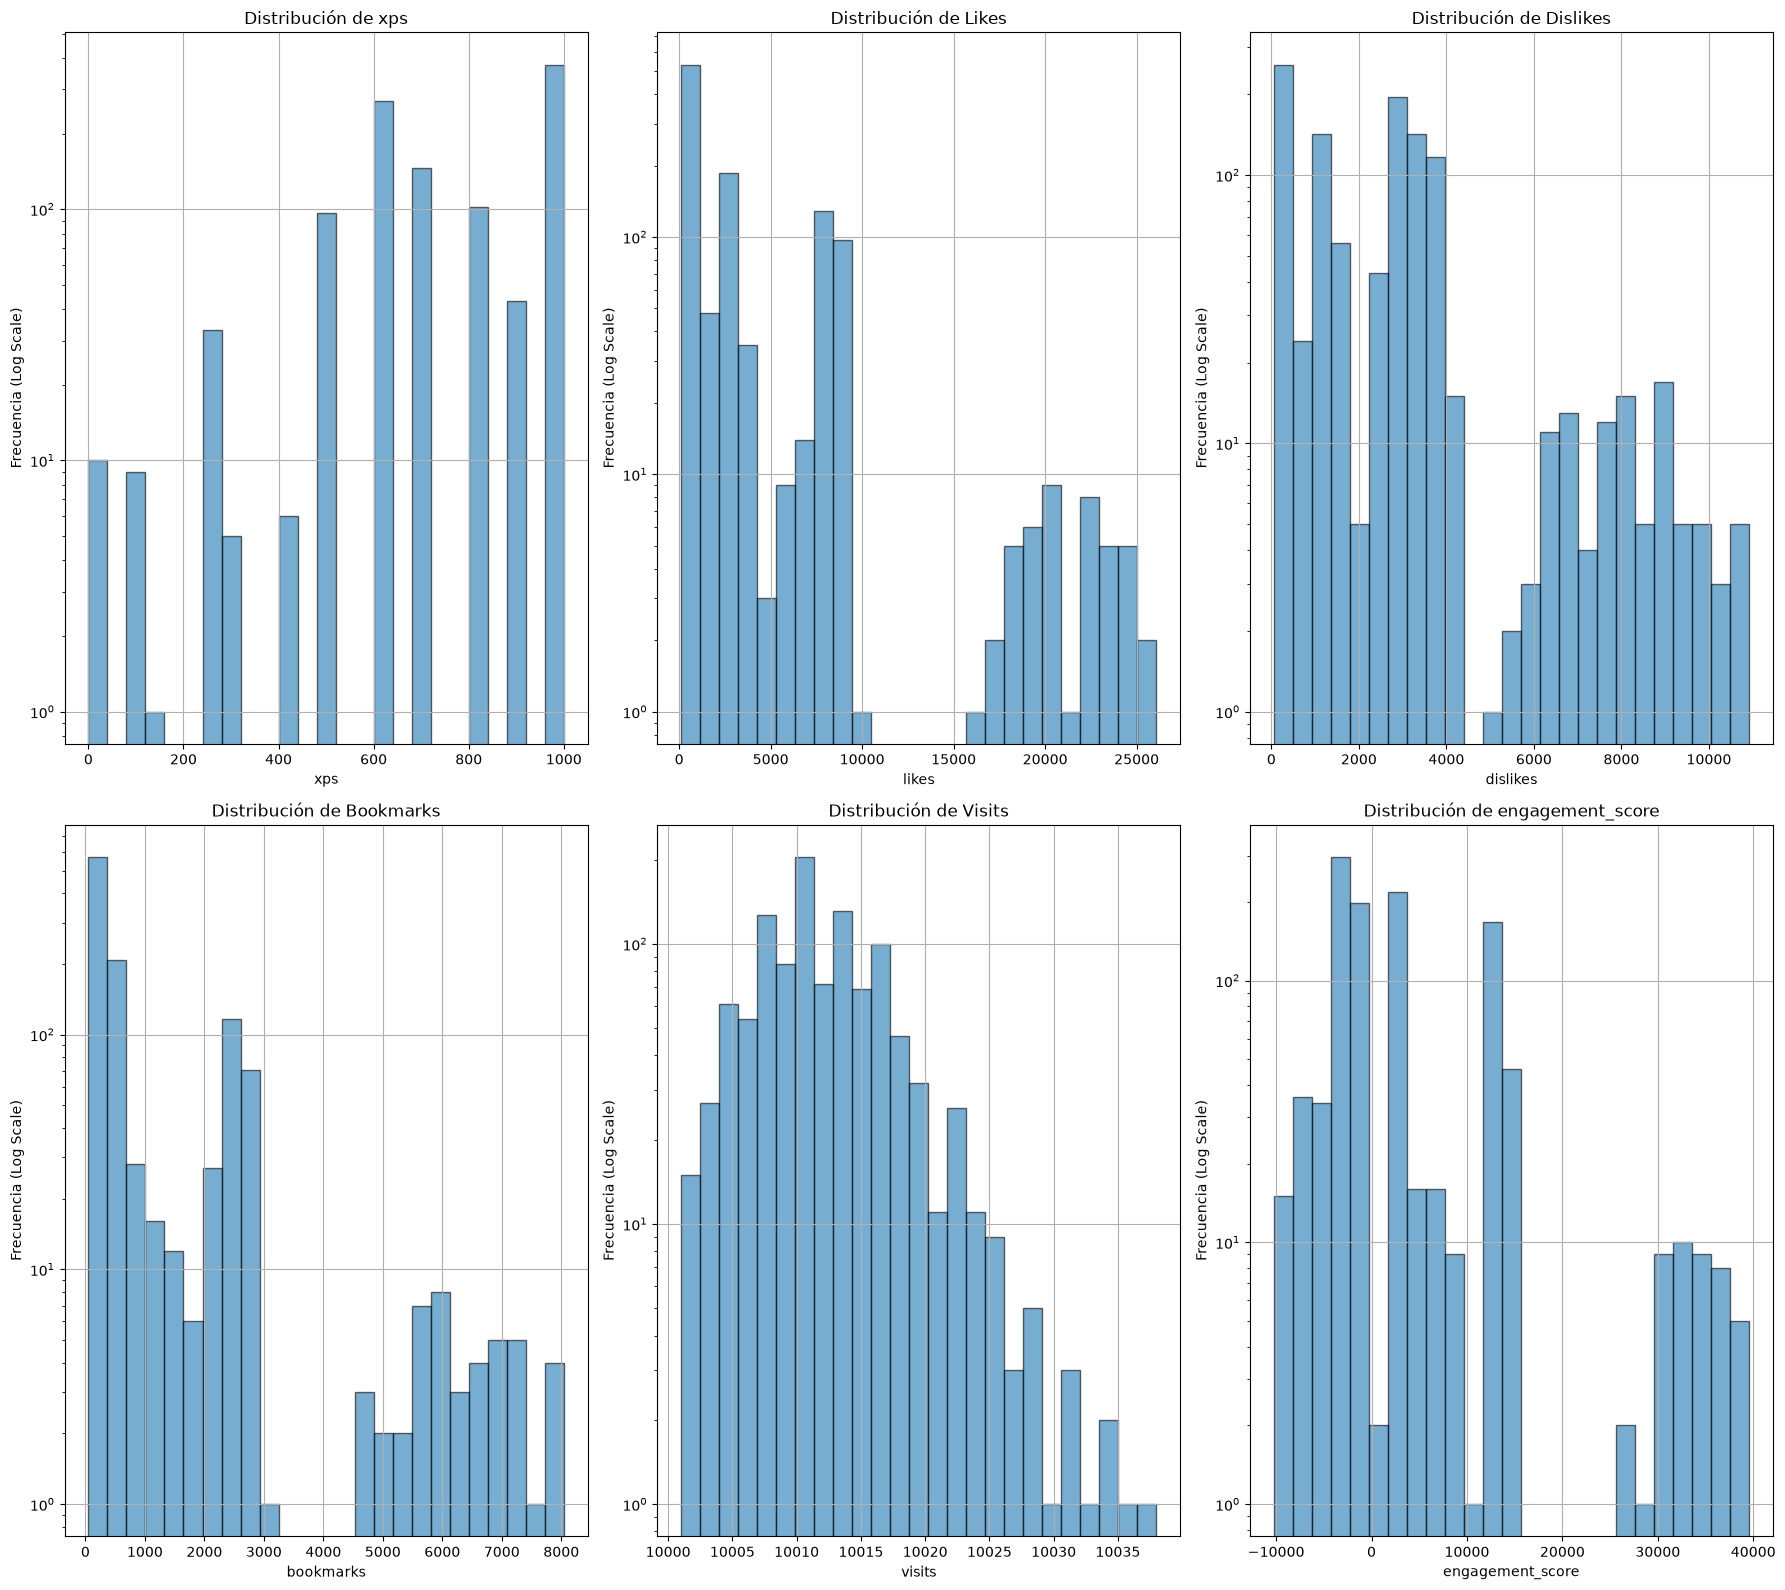

In [52]:

variables = [
    'xps', 'Likes', 'Dislikes',                  
    'Bookmarks', 'Visits','engagement_score'
]

cols_grid = 3
rows_grid = (len(variables) + cols_grid - 1) // cols_grid 

plt.figure(figsize=(18, 16)) 

for i, col in enumerate(variables):
    if col in df_train.columns:
        plt.subplot(rows_grid, cols_grid, i + 1)
        
        df_train[col].plot.hist(alpha=0.6, bins=25, grid=True, edgecolor='black')
        
        plt.yscale("log")
        
        plt.title(f'Distribución de {col}', fontsize=12)
        plt.xlabel(col.lower())
        plt.ylabel('Frecuencia (Log Scale)')
    else:
        print(f"⚠️ Alerta: La columna '{col}' no existe en el DataFrame.")
plt.tight_layout()
plt.show()

Agrupamos las variables de categorias y hacemos encoding para usarlas de forma mas eficiente

In [53]:
from sklearn.preprocessing import LabelEncoder

def agrupar_raros(serie, umbral=10):
    conteo = serie.value_counts()
    categorias_frecuentes = conteo[conteo >= umbral].index
    return serie.apply(lambda x: x if x in categorias_frecuentes else 'Otras')

df_train['categories_grouped'] = agrupar_raros(df_train['categories'].fillna('Desconocido'))
le_cat = LabelEncoder()
df_train['categories_encoded'] = le_cat.fit_transform(df_train['categories_grouped'])

df_val['categories_grouped'] = agrupar_raros(df_val['categories'].fillna('Desconocido'))
df_val['categories_encoded'] = le_cat.fit_transform(df_val['categories_grouped'])

df_test['categories_grouped'] = agrupar_raros(df_test['categories'].fillna('Desconocido'))
df_test['categories_encoded'] = le_cat.fit_transform(df_test['categories_grouped'])

display(df_train.describe())

,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks,engagement_score,target_engagement,categories_encoded
count,1098.00000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000
mean,1.54827,-1.225722,39.888077,748.816029,10012.009107,3617.775046,2510.412568,976.407104,3060.176685,0.500000,9.790528
std,0.63615,23.329326,9.622398,227.964040,5.431760,4757.120779,2229.322814,1433.866083,8991.623169,0.500228,8.933249
min,1.00000,-121.951049,-62.940930,0.000000,10001.000000,100.000000,52.000000,50.000000,-10256.000000,0.000000,0.000000
25%,1.00000,-3.725201,40.411073,600.000000,10008.000000,468.250000,890.750000,116.000000,-2851.750000,0.000000,0.000000
50%,1.00000,-3.699191,40.421193,700.000000,10011.000000,1437.500000,2711.000000,314.500000,-1608.000000,0.500000,10.000000
75%,2.00000,-3.670688,40.467015,1000.000000,10015.000000,7027.000000,3388.500000,1337.750000,7150.250000,1.000000,18.000000
max,4.00000,158.333118,64.800148,1000.000000,10038.000000,26084.000000,10918.000000,8043.000000,39566.000000,1.000000,26.000000


Contamos el numero de tags que tienen para usar la variable de tags

In [54]:
df_train['num_tags'] = df_train['tags'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df_val['num_tags'] = df_val['tags'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)
df_test['num_tags'] = df_test['tags'].fillna('').apply(lambda x: len(x.split(',')) if x else 0)

display(df_train.describe())

,tier,locationLon,locationLat,xps,Visits,Likes,Dislikes,Bookmarks,engagement_score,target_engagement,categories_encoded,num_tags
count,1098.00000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000,1098.000000
mean,1.54827,-1.225722,39.888077,748.816029,10012.009107,3617.775046,2510.412568,976.407104,3060.176685,0.500000,9.790528,8.547359
std,0.63615,23.329326,9.622398,227.964040,5.431760,4757.120779,2229.322814,1433.866083,8991.623169,0.500228,8.933249,4.523416
min,1.00000,-121.951049,-62.940930,0.000000,10001.000000,100.000000,52.000000,50.000000,-10256.000000,0.000000,0.000000,1.000000
25%,1.00000,-3.725201,40.411073,600.000000,10008.000000,468.250000,890.750000,116.000000,-2851.750000,0.000000,0.000000,4.000000
50%,1.00000,-3.699191,40.421193,700.000000,10011.000000,1437.500000,2711.000000,314.500000,-1608.000000,0.500000,10.000000,10.000000
75%,2.00000,-3.670688,40.467015,1000.000000,10015.000000,7027.000000,3388.500000,1337.750000,7150.250000,1.000000,18.000000,13.000000
max,4.00000,158.333118,64.800148,1000.000000,10038.000000,26084.000000,10918.000000,8043.000000,39566.000000,1.000000,26.000000,14.000000


Escalamos las variables numericas para normalizarlas, cabe recalcar que debemos entrenar el escalador con train y aplicarlo asi a validacion y test.

In [55]:

numeric_cols = [
    'tier',
    'locationLon',
    'locationLat',
    'xps',
    'categories_encoded',
    'num_tags'
]

scaler = StandardScaler()

df_train[numeric_cols] = scaler.fit_transform(df_train[numeric_cols])
df_val[numeric_cols] = scaler.transform(df_val[numeric_cols])
df_test[numeric_cols] = scaler.transform(df_test[numeric_cols])

Revisamos la matriz de correlación fijandonos en si nuestras variables predictivas tienen correlación alta para poder borrarlas en caso de que asi sea

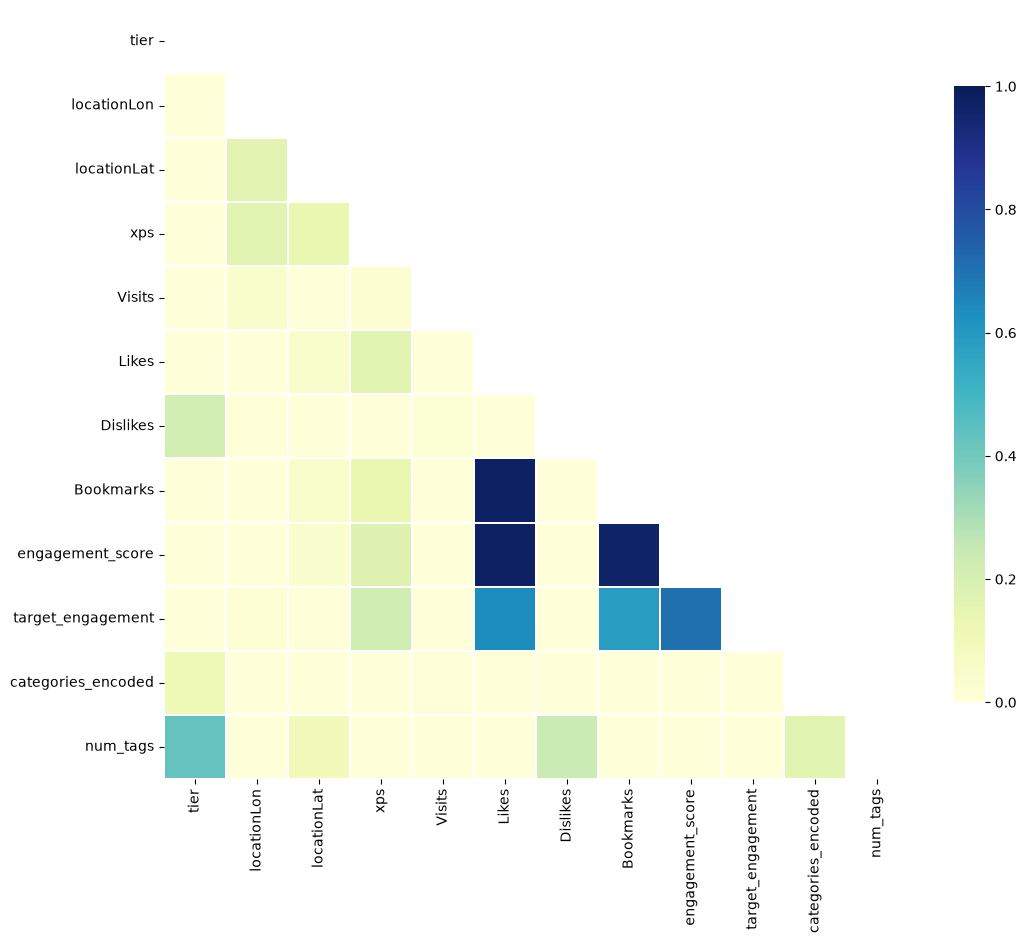

In [56]:
columnas_numericas = df_train.select_dtypes(include=[np.number])
corr = columnas_numericas.corr()

mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(corr, mask=mask,vmin = 0.0, vmax=1.0, center=0.5,
            linewidths=.1, cmap="YlGnBu", cbar_kws={"shrink": .8})

plt.show()

Normalizamos el tamaño de las imagenes a un numero de pixeles concreto tanto de ancho como de alto para preprocesarlas

In [57]:
IMG_WIDTH = 224
IMG_HEIGHT = 224

def preprocess_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize((IMG_WIDTH, IMG_HEIGHT))
        img_array = np.array(img) / 255.0
        return img_array
    except Exception as e:
        print(f"Error procesando la imagen {image_path}: {e}")
        return None

Hemos diseñado esta clase personalizada para manejar la naturaleza dual de mis datos, permitiendo que el modelo procese información de imagen y metadatos tabulares de manera sincronizada.

In [58]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image

class POIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
        columnas_metadatos = ['tier', 
                                'locationLat', 
                                'locationLon', 
                                'xps', 
                                'num_tags',
                                'categories_encoded']
        self.tabular_features = dataframe[columnas_metadatos].values
        
        self.labels = dataframe['target_engagement'].values
        self.image_paths = dataframe['main_image_path'].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        tab_data = torch.tensor(self.tabular_features[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.long) 
        return image, tab_data, label

Una vez definido el dataframe, configuro la transformación de imágenes y la carga en lotes (batches), pasos esenciales para que el modelo pueda procesar la información de forma eficiente.

Ademas añadimos rotaciones y cambios en las imagenes para que en cada epoch pueda encontrarse las imagenes cambiadas un poco y aprenda a generalizar

In [59]:
transformacion_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
])
transformaciones = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = POIDataset(df_train, transform=transformacion_train)
val_dataset = POIDataset(df_val, transform=transformaciones)
test_dataset = POIDataset(df_test, transform=transformaciones)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Hemos implementado una arquitectura de fusión tardía diseñada específicamente para procesar datos heterogéneos.

Teniendo dos ramas:

1.Rama Visual: Utilizamos ResNet18 preentrenada con ImageNet.
2.Rama Contextual: construimos una red fully connected que procesa los metadatos numéricos y categóricos.
Decisión: Incluí capas de Dropout(p=0.3) para regularizar el modelo.

3.Capa de Fusión (fusion): Aquí es donde ocurre la sinergia. Concateno los 128 atributos visuales con los 32 atributos tabulares.

Esto da un resultado dependiendo del numero de clases en este caso 2 al ser un clasificador simple.

In [60]:
class HybridEngagementModel(nn.Module):
    def __init__(self, num_tabular_features, num_classes=2):
        super(HybridEngagementModel, self).__init__()
        
        # Usamos ResNet18 pre-entrenada
        self.visual_model = models.resnet18(pretrained=True)
        
        # Modificamos la última capa de ResNet para que no clasifique en 1000 clases,
        num_ftrs = self.visual_model.fc.in_features
        self.visual_model.fc = nn.Linear(num_ftrs, 128)

        # Red neuronal densa (Fully Connected) para procesar los datos estructurados
        self.tabular_model = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3), # Previene el sobreajuste
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Concatenaremos los 128 atributos visuales + 32 atributos tabulares (Total = 160)
        self.fusion = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, image, tabular_data):
        visual_features = self.visual_model(image)
        tabular_features = self.tabular_model(tabular_data)
        combined = torch.cat((visual_features, tabular_features), dim=1)
        out = self.fusion(combined)
        return out

Preparamos el hardware y los hiperparámetros necesarios para el entrenamiento del modelo híbrido.

Función de Pérdida (CrossEntropyLoss): Ideal para problemas de clasificación multiclase (en este casp binaria). Mide la divergencia entre la distribución de probabilidad predicha y la etiqueta real.

Optimizador Adam: Utilizamos una tasa de aprendizaje de 0.001.

In [61]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

NUM_TABULAR_FEATURES = df_train[['tier', 
                                'locationLat', 
                                'locationLon', 
                                'xps', 
                                'num_tags',
                                'categories_encoded']].shape[1] 
model = HybridEngagementModel(num_tabular_features=NUM_TABULAR_FEATURES)
model = model.to(device)

# Función de pérdida para clasificación binaria
criterion = nn.CrossEntropyLoss()

# Optimizador Adam
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Entrenando en: cpu


c:\Users\Samuel\miniconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Samuel\miniconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Realizamos el aprendizaje del modelo con un numero de 10 epochs imprimiendo cual va siendo el resultado de cada epoch en validación. 
Además guardamos el mejor modelo cada vez que obtenemos una perdida menor que la anterior mas baja conseguida.

In [62]:
num_epochs = 20
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, tabular, labels in train_loader:
        images = images.to(device)
        tabular = tabular.to(device)
        labels = labels.to(device)
        
        # Reiniciar gradientes
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images, tabular)
        
        # Calcular la pérdida
        loss = criterion(outputs, labels)
        
        # Backward pass y optimizar
        loss.backward()
        optimizer.step()
        
        # Estadísticas
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * correct_train / total_train
    
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # torch.no_grad() ahorra memoria ya que no necesitamos calcular gradientes aquí
    with torch.no_grad():
        for images, tabular, labels in val_loader:
            images = images.to(device)
            tabular = tabular.to(device)
            labels = labels.to(device)
            
            outputs = model(images, tabular)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * correct_val / total_val
    
    print(f'Epoch [{epoch+1}/{num_epochs}] | '
          f'Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}% | '
          f'Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), '../models/best_engagement_model.pth')
        print("  --> ¡Mejor modelo guardado!")

Epoch [1/20] | Train Loss: 0.6018, Train Acc: 69.03% | Val Loss: 0.6429, Val Acc: 68.94%
  --> ¡Mejor modelo guardado!
Epoch [2/20] | Train Loss: 0.5456, Train Acc: 75.23% | Val Loss: 0.5999, Val Acc: 66.38%
  --> ¡Mejor modelo guardado!
Epoch [3/20] | Train Loss: 0.5469, Train Acc: 73.22% | Val Loss: 0.5944, Val Acc: 71.06%
  --> ¡Mejor modelo guardado!
Epoch [4/20] | Train Loss: 0.4878, Train Acc: 78.05% | Val Loss: 0.7672, Val Acc: 69.79%
Epoch [5/20] | Train Loss: 0.4696, Train Acc: 77.50% | Val Loss: 0.6094, Val Acc: 68.94%
Epoch [6/20] | Train Loss: 0.4471, Train Acc: 79.33% | Val Loss: 0.7182, Val Acc: 71.49%
Epoch [7/20] | Train Loss: 0.4476, Train Acc: 79.87% | Val Loss: 0.5053, Val Acc: 79.57%
  --> ¡Mejor modelo guardado!
Epoch [8/20] | Train Loss: 0.4341, Train Acc: 82.51% | Val Loss: 0.5594, Val Acc: 76.60%
Epoch [9/20] | Train Loss: 0.4251, Train Acc: 81.69% | Val Loss: 0.5918, Val Acc: 74.89%
Epoch [10/20] | Train Loss: 0.4077, Train Acc: 82.79% | Val Loss: 0.5270, Val A

Imprimimos las métricas de evaluación sobre test y realizamos la matriz de confusión

Evaluando el modelo en el conjunto de Test...

--- Reporte de Clasificación ---
                     precision    recall  f1-score   support

Bajo Engagement (0)       0.83      0.83      0.83       118
Alto Engagement (1)       0.83      0.83      0.83       118

           accuracy                           0.83       236
          macro avg       0.83      0.83      0.83       236
       weighted avg       0.83      0.83      0.83       236



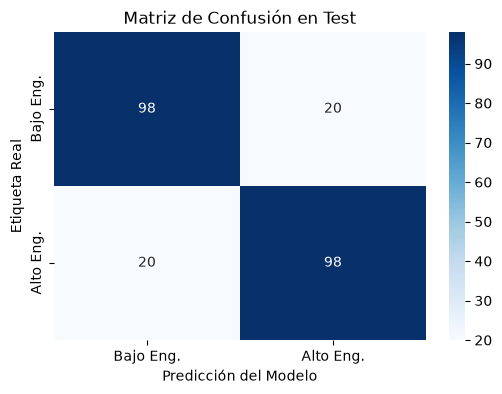

In [66]:
#Cargar los pesos del mejor modelo guardado

model.load_state_dict(torch.load('../models/best_engagement_model.pth'))
model.eval()

y_true = []
y_pred = []

print("Evaluando el modelo en el conjunto de Test...")
with torch.no_grad():
    for images, tabular, labels in test_loader:
        images = images.to(device)
        tabular = tabular.to(device)
        labels = labels.to(device)
        
        outputs = model(images, tabular)
        _, predicted = torch.max(outputs.data, 1)
        
        # Guardamos las predicciones y etiquetas reales para el reporte
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

#Generar métricas de rendimiento
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_true, y_pred, target_names=['Bajo Engagement (0)', 'Alto Engagement (1)']))

#Matriz de Confusión Visual
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bajo Eng.', 'Alto Eng.'], 
            yticklabels=['Bajo Eng.', 'Alto Eng.'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.title('Matriz de Confusión en Test')
plt.show()

El modelo muestra un rendimiento sólido y equilibrado en el conjunto de prueba, alcanzando una precisión del 83 %. 
Además, las métricas de precisión, recall y F1-score son similares para ambas clases, lo que indica que el modelo no presenta un sesgo importante hacia ninguna de ellas y es capaz de distinguir de manera consistente entre contenidos de bajo y alto engagement.